=== Loaded train.csv for neural network ===
X shape: (21263, 81)
y shape: (21263,)

=== Train/Validation Split ===
Train size: 18073
Validation size: 3190

Using device: cpu

=== Data standardization complete ===
X_train_scaled shape: (18073, 81)
X_train_scaled mean (should be ~0): -0.000000
X_train_scaled std (should be ~1): 1.000000

=== Neural Network Architecture ===
Enhanced_NN(
  (model): Sequential(
    (0): Linear(in_features=81, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_sta

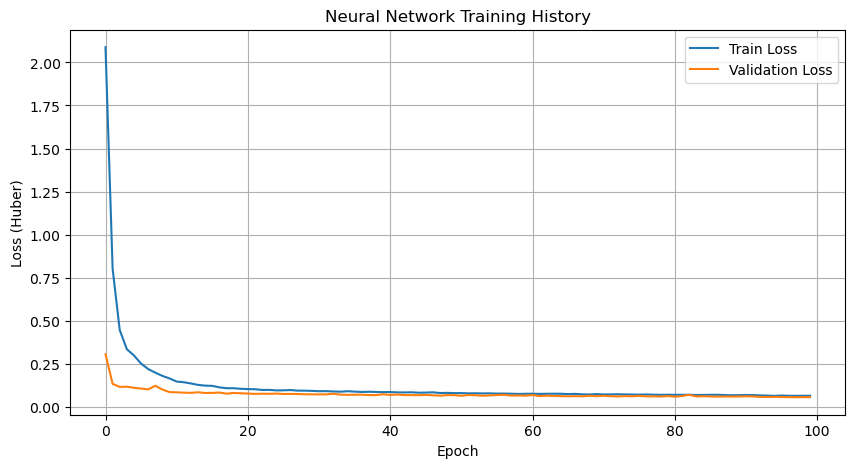


=== Neural Network Performance on Validation Set ===
Val MSE:  137.5290
Val RMSE: 11.7273 K
Val R^2:  0.8807

=== Model Comparison (Validation Set) ===
Neural Net   - RMSE: 11.7273 K, R²: 0.8807



In [5]:
# ============================================================
# 4. Simple Neural Network for Temperature Prediction
#    Using PyTorch for a feedforward neural network
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# Load train.csv
data_path = "train.csv"
df = pd.read_csv(data_path)

# If the target column is not named 'critical_temp', adjust here:
if "critical_temp" in df.columns:
    target_col = "critical_temp"
else:
    # assume last column is the target
    target_col = df.columns[-1]
    print(f"WARNING: 'critical_temp' not found; using last column '{target_col}' as target.")

X = df.drop(columns=[target_col])
y = df[target_col]

print("=== Loaded train.csv for neural network ===")
print("X shape:", X.shape)
print("y shape:", y.shape)
print()

# Split into train and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42
)

print("=== Train/Validation Split ===")
print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print()

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print()

# Standardize features (important for neural networks)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)

# Reshape y for scaler (needs 2D array)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()

print("=== Data standardization complete ===")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_train_scaled mean (should be ~0): {X_train_scaled.mean():.6f}")
print(f"X_train_scaled std (should be ~1): {X_train_scaled.std():.6f}")
print()

# Create PyTorch Dataset
class SuperconductorDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SuperconductorDataset(X_train_scaled, y_train_scaled)
val_dataset = SuperconductorDataset(X_val_scaled, y_val_scaled)

# Improvement testing: increased batch size to 128 (helps Batch Normalization statistics)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# Define Enhanced neural network (Upgraded with BatchNorm + GELU)
class Enhanced_NN(nn.Module):
    def __init__(self, input_size, hidden_sizes=[256, 128, 64], dropout_rate=0.2):
        super(Enhanced_NN, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            
            # Improvement: Batch Normalization (stabilizes training)
            layers.append(nn.BatchNorm1d(hidden_size))
            
            # Improvement: GELU activation (smoother than ReLU)
            layers.append(nn.GELU())
            
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # Output layer (single value for temperature)
        layers.append(nn.Linear(prev_size, 1))
        
        self.model = nn.Sequential(*layers)
        
        # Improvement: Kaiming Initialization (optimal for deep networks)
        self.model.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.model(x).squeeze()

# Initialize model
input_size = X_train_scaled.shape[1]
model = Enhanced_NN(input_size, hidden_sizes=[256, 128, 64], dropout_rate=0.2).to(device)

print("=== Neural Network Architecture ===")
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print()

# Loss function and optimizer
# Improvement: HuberLoss is more robust to outliers than MSELoss
criterion = nn.HuberLoss(delta=1.0)
# Improvement: AdamW generalizes better than Adam
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Fix: Removed 'verbose=True' (deprecated in newer PyTorch)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Training loop
num_epochs = 100
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 20
patience_counter = 0

print("=== Training Neural Network ===")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        # Improvement: Gradient Clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)

    # Improvement: Manual LR print since verbose=True is removed
    current_lr = optimizer.param_groups[0]['lr']
    if 'last_lr' not in locals(): last_lr = current_lr
    if current_lr != last_lr:
        print(f"    --> Learning Rate reduced to {current_lr:.6f}")
        last_lr = current_lr
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_nn_model.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(torch.load('best_nn_model.pth'))

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.title('Neural Network Training History')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate on validation set (in original scale)
model.eval()
with torch.no_grad():
    X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
    y_val_pred_scaled = model(X_val_tensor).cpu().numpy()

# Inverse transform predictions
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()

# Calculate metrics
mse_nn = mean_squared_error(y_val, y_val_pred)
rmse_nn = mse_nn ** 0.5
r2_nn = r2_score(y_val, y_val_pred)

print("\n=== Neural Network Performance on Validation Set ===")
print(f"Val MSE:  {mse_nn:.4f}")
print(f"Val RMSE: {rmse_nn:.4f} K")
print(f"Val R^2:  {r2_nn:.4f}")
print()

# Compare with previous models (if they exist)
try:
    print("=== Model Comparison (Validation Set) ===")
    if 'rmse_rf' in globals() and 'r2_rf' in globals():
        print(f"Random Forest - RMSE: {rmse_rf:.4f} K, R²: {r2_rf:.4f}")
    if 'rmse_xgb' in globals() and 'r2_xgb' in globals():
        print(f"XGBoost      - RMSE: {rmse_xgb:.4f} K, R²: {r2_xgb:.4f}")
    print(f"Neural Net   - RMSE: {rmse_nn:.4f} K, R²: {r2_nn:.4f}")
    print()
except:
    print("=== Neural Network Results ===")
    print(f"RMSE: {rmse_nn:.4f} K")
    print(f"R²: {r2_nn:.4f}")
    print()